In [52]:
from google.colab import files
uploaded=files.upload()

Saving amazon_sales_data 2025 (1) - amazon_sales_data 2025 (1).csv to amazon_sales_data 2025 (1) - amazon_sales_data 2025 (1) (1).csv


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
df=pd.read_csv("amazon_sales_data 2025 (1) - amazon_sales_data 2025 (1).csv")

In [55]:
# 1. Data inspection

In [56]:
print(df.head())

  Order ID      Date        Product     Category  Price  Quantity  \
0  ORD0001  14-03-25  Running Shoes     Footwear     60         3   
1  ORD0002  20-03-25     Headphones  Electronics    100         4   
2  ORD0003  15-02-25  Running Shoes     Footwear     60         2   
3  ORD0004  19-02-25  Running Shoes     Footwear     60         3   
4  ORD0005  10-03-25     Smartwatch  Electronics    150         3   

   Total Sales  Customer Name Customer Location Payment Method     Status  
0          180     Emma Clark          New York     Debit Card  Cancelled  
1          400  Emily Johnson     San Francisco     Debit Card    Pending  
2          120       John Doe            Denver     Amazon Pay  Cancelled  
3          180  Olivia Wilson            Dallas    Credit Card    Pending  
4          450     Emma Clark          New York     Debit Card    Pending  


In [57]:
print(df.shape)

(250, 11)


In [58]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Order ID           250 non-null    object
 1   Date               250 non-null    object
 2   Product            250 non-null    object
 3   Category           250 non-null    object
 4   Price              250 non-null    int64 
 5   Quantity           250 non-null    int64 
 6   Total Sales        250 non-null    int64 
 7   Customer Name      250 non-null    object
 8   Customer Location  250 non-null    object
 9   Payment Method     250 non-null    object
 10  Status             250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB
None


In [59]:
print(df.isnull().sum())

Order ID             0
Date                 0
Product              0
Category             0
Price                0
Quantity             0
Total Sales          0
Customer Name        0
Customer Location    0
Payment Method       0
Status               0
dtype: int64


In [60]:
print(df.duplicated().sum())

0


In [61]:
print(df.describe())

             Price    Quantity  Total Sales
count   250.000000  250.000000   250.000000
mean    343.580000    2.856000   975.380000
std     380.635808    1.429489  1252.112254
min      15.000000    1.000000    15.000000
25%      40.000000    2.000000   100.000000
50%     150.000000    3.000000   400.000000
75%     600.000000    4.000000  1500.000000
max    1200.000000    5.000000  6000.000000


In [62]:
print("data inspection completed")

data inspection completed


In [63]:
# 2. Data cleaning

In [64]:
df=df.drop_duplicates()

In [65]:

df['Date']=pd.to_datetime(df['Date'],errors='coerce')

/tmp/ipykernel_1447/3319946642.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date']=pd.to_datetime(df['Date'],errors='coerce')


In [66]:

column_to_fill = 'Price'
df[column_to_fill] = df[column_to_fill].fillna(df[column_to_fill].median())

In [67]:
categorical_columns = df.select_dtypes(include=['object']).columns

In [68]:
df[categorical_columns] = df[categorical_columns].fillna(
    df[categorical_columns].mode().iloc[0]
)

In [69]:
df[categorical_columns] = (
    df[categorical_columns]
    .apply(lambda x: x.str.strip())
    .apply(lambda x: x.str.title())
)

In [70]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)

In [71]:
IQR = Q3 - Q1

In [72]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [73]:
for col in numerical_columns:
    df[col] = np.where(df[col] < lower_limit[col], lower_limit[col], df[col])
    df[col] = np.where(df[col] > upper_limit[col], upper_limit[col], df[col])

In [74]:
print("data cleaning completed")

data cleaning completed


In [75]:
# 3. Feature engineering

In [76]:
df['Month'] = df['Date'].dt.month_name()

In [77]:
df['average order value']=df['Total Sales']/df['Quantity']

In [78]:
encoded_df=pd.get_dummies(df,drop_first=True)

In [79]:
print("feature engineering completed")

feature engineering completed


In [80]:
# 4. EDA

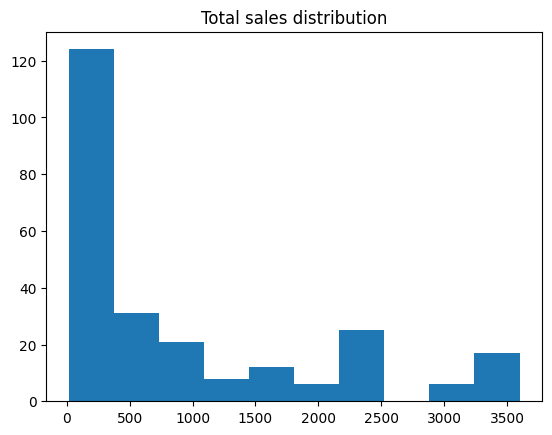

In [81]:
# 1. histogram
plt.hist(df['Total Sales'],bins=10)
plt.title("Total sales distribution")
plt.show()

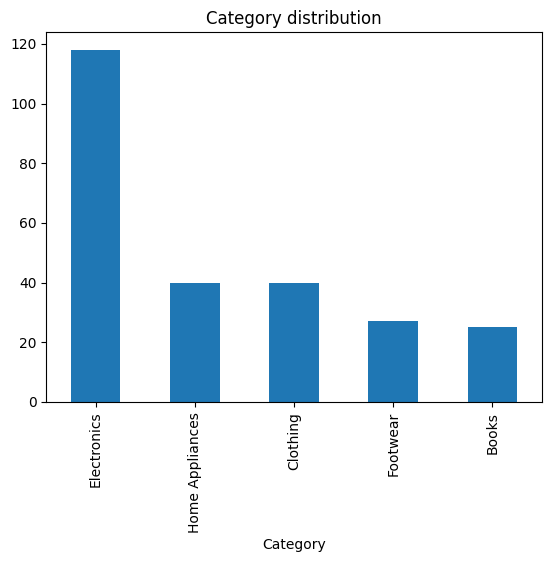

In [82]:
# 2. bar chart
df['Category'].value_counts().plot(kind='bar')
plt.title("Category distribution")
plt.show()

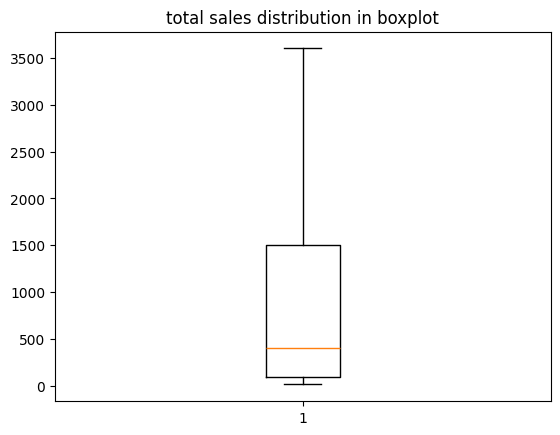

In [83]:
# 3. box plot
plt.boxplot(df['Total Sales'])
plt.title("total sales distribution in boxplot")
plt.show()

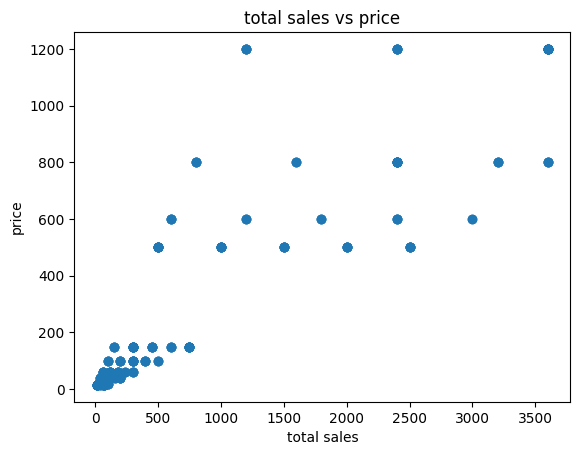

In [84]:
# 4. scatter plot
plt.scatter(df['Total Sales'],df['Price'])
plt.xlabel("total sales")
plt.ylabel("price")
plt.title("total sales vs price")
plt.show()

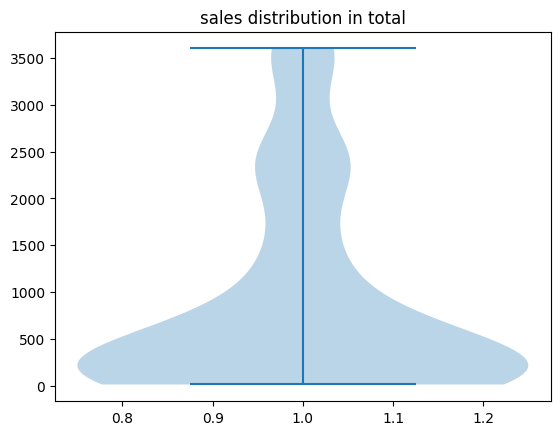

In [89]:
# violin plot
plt.violinplot(df['Total Sales'])
plt.title("sales distribution in total")
plt.show()

In [85]:
corr=df.corr(numeric_only=True)

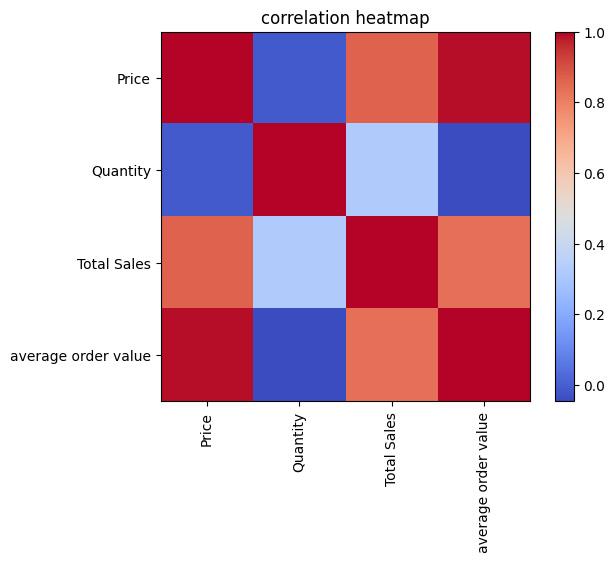

In [86]:
# correlation heatmap
plt.imshow(corr,cmap='coolwarm',interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr)),corr.columns,rotation=90)
plt.yticks(range(len(corr)),corr.columns)
plt.title("correlation heatmap")
plt.show()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

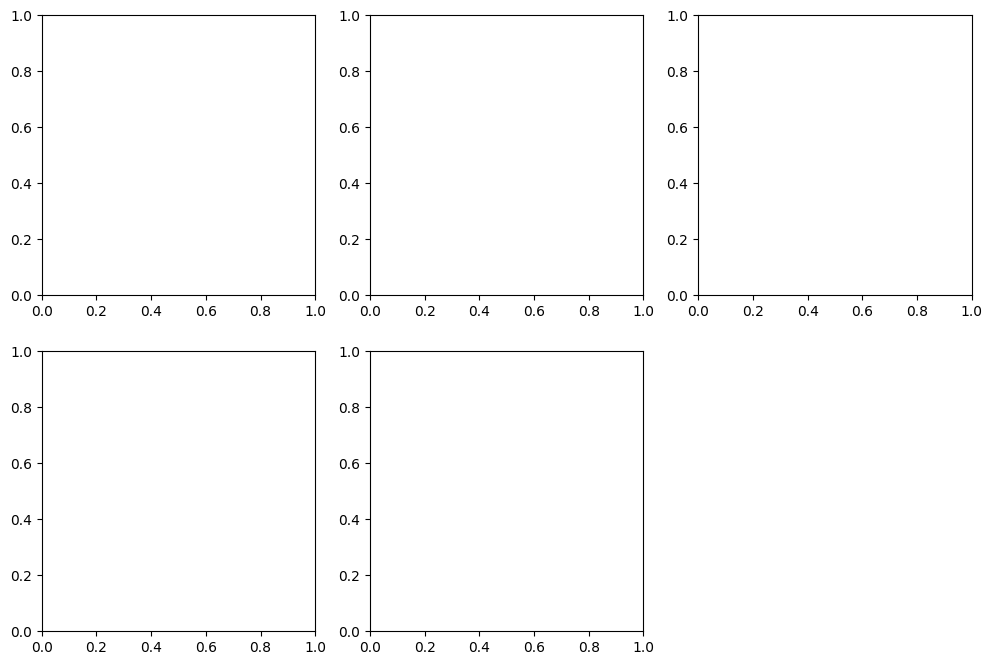

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[1,2].axis('off')

In [88]:
plt.figure(figsize=(10, 6))


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>